In [1]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
from transformers import AutoImageProcessor, SwinForImageClassification
from tqdm import tqdm
import os
import shutil
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator, img_to_array, load_img, save_img
from collections import Counter
from transformers import SwinForImageClassification, SwinConfig
import torch.nn as nn

2025-05-04 12:21:30.600220: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1746361291.038652      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1746361291.162811      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [ ]:
data_dir = "/kaggle/working/augment"
batch_size =32
num_epochs = 10
learning_rate = 1e-4
IMAGE_HEIGHT,IMAGE_WIDTH = 224,224 
num_of_img = 5
desired_count = 1349


In [ ]:
import os
import shutil
import numpy as np
from tqdm import tqdm
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array, save_img

original_dataset_dir = '/kaggle/input/original-eye-disease-image-dataset-mendeley/Original Dataset'
balanced_dataset_dir = '/kaggle/working/augment'
target_size = (IMAGE_HEIGHT, IMAGE_WIDTH)

if os.path.exists(balanced_dataset_dir):
    shutil.rmtree(balanced_dataset_dir)
os.makedirs(balanced_dataset_dir)

augmenter = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

for cls in tqdm(os.listdir(original_dataset_dir), desc="Oversampling classes"):
    input_dir = os.path.join(original_dataset_dir, cls)
    if not os.path.isdir(input_dir):
        continue

    output_dir = os.path.join(balanced_dataset_dir, cls)
    os.makedirs(output_dir, exist_ok=True)

    images = [f for f in os.listdir(input_dir) if f.lower().endswith(('png', 'jpg', 'jpeg'))]
    for img_name in images:
        shutil.copy(os.path.join(input_dir, img_name), os.path.join(output_dir, img_name))

    current_count = len(images)

    if 'desired_count_per_class' in locals():
        target_count = desired_count_per_class.get(cls, current_count)
    else:
        target_count = desired_count

    n_to_generate = target_count - current_count
    if n_to_generate <= 0:
        continue

    i = 0
    while i < n_to_generate:
        img_name = np.random.choice(images)
        img_path = os.path.join(input_dir, img_name)
        img = load_img(img_path, target_size=target_size)
        x = img_to_array(img)
        x = np.expand_dims(x, axis=0)

        for batch in augmenter.flow(x, batch_size=1):
            aug_img_path = os.path.join(output_dir, f'aug_{i}_{img_name}')
            save_img(aug_img_path, batch[0])
            i += 1
            if i >= n_to_generate:
                break


Oversampling classes: 100%|██████████| 10/10 [02:41<00:00, 16.16s/it]


In [ ]:
image_processor = AutoImageProcessor.from_pretrained(checkpoint)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=image_processor.image_mean, std=image_processor.image_std)
])

In [ ]:
full_dataset = datasets.ImageFolder(root=data_dir, transform=transform)
num_classes = len(full_dataset.classes)
class_names = full_dataset.classes

train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

In [ ]:
import torch
import torch.nn as nn
from torchvision.models import inception_v3
import timm
import torchvision.transforms as transforms
import torch.nn.functional as F
from torch.optim.lr_scheduler import CosineAnnealingLR, LinearLR
from tqdm import tqdm
import torch.nn.functional as F

class FocalLoss(nn.Module):
    def __init__(self, gamma=2, alpha=None):
        super(FocalLoss, self).__init__()
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, inputs, targets):
        CE_loss = F.cross_entropy(inputs, targets, reduction='none', weight=self.alpha)
        pt = torch.exp(-CE_loss)
        F_loss = ((1 - pt) ** self.gamma) * CE_loss
        return torch.mean(F_loss)

class CenterLoss(nn.Module):
    def __init__(self, num_classes, feat_dim, device='cpu'):
        super(CenterLoss, self).__init__()
        self.centers = nn.Parameter(torch.randn(num_classes, feat_dim).to(device))

    def forward(self, features, labels):
        batch_size = features.size(0)
        centers_batch = self.centers[labels]
        return ((features - centers_batch) ** 2).sum() / batch_size


class InceptionFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        self.inception = inception_v3(pretrained=True, aux_logits=True)
        
        self.inception.aux_logits = False
        self.inception.AuxLogits = None
        
        self.inception.fc = nn.Identity()
        self.output_dim = 2048

        for param in self.inception.parameters():
            param.requires_grad = False

        self.transform = transforms.Compose([
            transforms.Resize((299,299)),
            transforms.CenterCrop(299),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], 
                               std=[0.229, 0.224, 0.225]),
        ])

    def forward(self, x):
        if x.dim() == 4:
            x = self.transform(x)
        elif x.dim() == 2:
            batch_size = x.shape[0]
            x = x.view(batch_size, 3, 224, 224)
            x = self.transform(x)
        else:
            raise RuntimeError(f"Input must be 4D or 2D. Got: {x.shape}")

        return self.inception(x)

class FeatureCombiner(nn.Module):
    def __init__(self, inception_dim=2048, swin_dim=768, hidden_dim=1024):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(inception_dim + swin_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, inception_dim + swin_dim),
            nn.Sigmoid()
        )
        
        self.transform = nn.Sequential(
            nn.Linear(inception_dim + swin_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.ReLU(),
            nn.Dropout(0.3)
        )
        
    def forward(self, inception_feat, swin_feat):
        combined = torch.cat([inception_feat, swin_feat], dim=1)
        
        attention_weights = self.attention(combined)
        attended_features = combined * attention_weights
        
        transformed = self.transform(attended_features)
        return transformed

class InceptionSwinHybrid(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.inception = InceptionFeatureExtractor()
        self.swin = timm.create_model(
            'swin_tiny_patch4_window7_224', 
            pretrained=True, 
            num_classes=0,
            global_pool='avg'
        )
        self.swin_output_dim = 768
        
        self.combiner = FeatureCombiner()
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=1024,
            nhead=8,
            dim_feedforward=2048,
            dropout=0.1
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=2)
        
        self.classifier = nn.Linear(1024, num_classes)
        
        for param in self.swin.parameters():
            param.requires_grad = False

    def forward(self, x):
        inc_feat = self.inception(x)
        swin_feat = self.swin(x)
        
        combined = self.combiner(inc_feat, swin_feat)
        
        transformer_input = combined.unsqueeze(1)
        encoded = self.transformer_encoder(transformer_input)
        encoded = encoded.squeeze(1)
        
        return self.classifier(encoded)

    def extract_features(self, x):
        inc_feat = self.inception(x)
        swin_feat = self.swin(x)
        combined = self.combiner(inc_feat, swin_feat)
        transformer_input = combined.unsqueeze(1)
        encoded = self.transformer_encoder(transformer_input)
        return encoded.squeeze(1)


def progressive_unfreeze(model, current_epoch):

    layer_map = {
        3: ["layers.3", "layers.2"],
        6: ["layers.1", "layers.0"],
        8: ["patch_embed", "norm"]
    }

    for target_epoch, layers in layer_map.items():
        if current_epoch >= target_epoch:
            if isinstance(layers, str):
                layers = [layers]
            for layer_name in layers:
                submodule = model.swin
                for attr in layer_name.split('.'):
                    if attr.isdigit():
                        submodule = submodule[int(attr)]
                    else:
                        submodule = getattr(submodule, attr, None)
                        if submodule is None:
                            print(f"[Warning] Layer '{layer_name}' not found in model.")
                            break
                if submodule is not None:
                    for param in submodule.parameters():
                        param.requires_grad = True
                    print(f"[Unfreeze] Epoch {current_epoch}: Unfroze layer '{layer_name}'")


In [ ]:
def train_model(model, train_loader, val_loader, num_epochs=10, lr=3e-4):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    if torch.cuda.device_count() > 1:
        print(f"Using {torch.cuda.device_count()} GPUs!")
        model = nn.DataParallel(model)

    model = model.to(device)

    model.center_loss = CenterLoss(num_classes=10, feat_dim=1024, device=device).to(device)

    weights = torch.tensor([1.0]*10)
    weights[3] = 3.0 
    weights[6] = 3.0 
    weights = weights.to(device)

    criterion = FocalLoss(gamma=2, alpha=weights)

    optimizer = torch.optim.AdamW([
        {'params': model.module.inception.parameters(), 'lr': lr * 0.1},
        {'params': model.module.swin.parameters(), 'lr': lr},
        {'params': model.module.combiner.parameters()},
        {'params': model.module.transformer_encoder.parameters()},
        {'params': model.module.classifier.parameters()}
    ], lr=lr, weight_decay=1e-4)

    warmup_scheduler = LinearLR(optimizer, start_factor=0.33, total_iters=1)
    cosine_scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs - 1, eta_min=1e-5)

    train_losses, val_losses = [], []
    train_accuracies, val_accuracies = [], []

    for epoch in range(num_epochs):
        if epoch == 0:
            warmup_scheduler.step()
        else:
            cosine_scheduler.step()

        progressive_unfreeze(model.module if isinstance(model, nn.DataParallel) else model, epoch + 1)

        model.train()
        running_loss, correct, total = 0.0, 0, 0
        train_loader_tqdm = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)

        for inputs, labels in train_loader_tqdm:
            inputs = inputs.float().to(device)
            labels = labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)

            m = model.module if isinstance(model, nn.DataParallel) else model
            loss = criterion(outputs, labels)

            if hasattr(m, 'center_loss') and hasattr(m, 'extract_features'):
                features = m.extract_features(inputs)
                center_loss_val = m.center_loss(features, labels)
                loss += 0.1 * center_loss_val

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            train_loader_tqdm.set_postfix({
                'Train Loss': f'{running_loss / total:.4f}',
                'Train Acc': f'{correct / total:.4f}',
                'LR': f'{optimizer.param_groups[0]["lr"]:.2e}'
            })

        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = correct / total
        train_losses.append(epoch_train_loss)
        train_accuracies.append(epoch_train_acc)

        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_loader_tqdm = tqdm(val_loader, desc='Validation', leave=False)

        with torch.no_grad():
            for inputs, labels in val_loader_tqdm:
                inputs = inputs.float().to(device)
                labels = labels.to(device)
                outputs = model(inputs)

                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

                val_loader_tqdm.set_postfix({
                    'Val Loss': f'{val_loss / val_total:.4f}',
                    'Val Acc': f'{val_correct / val_total:.4f}'
                })

        epoch_val_loss = val_loss / len(val_loader.dataset)
        epoch_val_acc = val_correct / val_total
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_val_acc)

        print(f"Epoch {epoch+1}/{num_epochs} | "
              f"Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.4f} | "
              f"Val Loss: {epoch_val_loss:.4f}, Val Acc: {epoch_val_acc:.4f} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}")

    return {
        'train_losses': train_losses,
        'val_losses': val_losses,
        'train_accuracies': train_accuracies,
        'val_accuracies': val_accuracies
    }


In [ ]:
num_classes = 10
model = InceptionSwinHybrid(num_classes=num_classes).to(device)
history = train_model(model, train_loader, val_loader, num_epochs=10)


Using 2 GPUs!


Epoch 1/10 | Train Loss: 0.7318, Train Acc: 0.7845 | Val Loss: 0.5482, Val Acc: 0.8355 | LR: 3.00e-05


Epoch 2/10 | Train Loss: 0.5822, Train Acc: 0.8082 | Val Loss: 0.4993, Val Acc: 0.8667 | LR: 2.94e-05
[Unfreeze] Epoch 3: Unfroze layer 'layers.3'
[Unfreeze] Epoch 3: Unfroze layer 'layers.2'


Epoch 3/10 | Train Loss: 0.6421, Train Acc: 0.7923 | Val Loss: 0.4139, Val Acc: 0.8304 | LR: 2.77e-05
[Unfreeze] Epoch 4: Unfroze layer 'layers.3'
[Unfreeze] Epoch 4: Unfroze layer 'layers.2'


Epoch 4/10 | Train Loss: 0.4851, Train Acc: 0.8422 | Val Loss: 0.3845, Val Acc: 0.8813 | LR: 2.50e-05
[Unfreeze] Epoch 5: Unfroze layer 'layers.3'
[Unfreeze] Epoch 5: Unfroze layer 'layers.2'


...

Epoch 6/10 | Train Loss: 0.3432, Train Acc: 0.8892 | Val Loss: 0.3317, Val Acc: 0.8905 | LR: 1.83e-05
[Unfreeze] Epoch 7: Unfroze layer 'layers.3'
[Unfreeze] Epoch 7: Unfroze layer 'layers.2'
[Unfreeze] Epoch 7: Unfroze layer 'layers.1'
[Unfreeze] Epoch 7: Unfroze layer 'layers.0'


Epoch 7/10 | Train Loss: 0.2789, Train Acc: 0.9035 | Val Loss: 0.3031, Val Acc: 0.9073 | LR: 1.50e-05
[Unfreeze] Epoch 8: Unfroze layer 'layers.3'
[Unfreeze] Epoch 8: Unfroze layer 'layers.2'
[Unfreeze] Epoch 8: Unfroze layer 'layers.1'
[Unfreeze] Epoch 8: Unfroze layer 'layers.0'
[Unfreeze] Epoch 8: Unfroze layer 'patch_embed'
[Unfreeze] Epoch 8: Unfroze layer 'norm'


Epoch 8/10 | Train Loss: 0.2159, Train Acc: 0.9278 | Val Loss: 0.3137, Val Acc: 0.9161 | LR: 1.23e-05
[Unfreeze] Epoch 9: Unfroze layer 'layers.3'
[Unfreeze] Epoch 9: Unfroze layer 'layers.2'
[Unfreeze] Epoch 9: Unfroze layer 'layers.1'
[Unfreeze] Epoch 9: Unfroze layer 'layers.0'
[Unfreeze] Epoch 9: Unfroze layer 'patch_embed'
[Unfreeze] Epoch 9: Unfroze layer 'norm'


Epoch 9/10 | Train Loss: 0.1787, Train Acc: 0.9374 | Val Loss: 0.3105, Val Acc: 0.9150 | LR: 1.06e-05
[Unfreeze] Epoch 10: Unfroze layer 'layers.3'
[Unfreeze] Epoch 10: Unfroze layer 'layers.2'
[Unfreeze] Epoch 10: Unfroze layer 'layers.1'
[Unfreeze] Epoch 10: Unfroze layer 'layers.0'
[Unfreeze] Epoch 10: Unfroze layer 'patch_embed'
[Unfreeze] Epoch 10: Unfroze layer 'norm'


Epoch 10/10 | Train Loss: 0.1542, Train Acc: 0.9452 | Val Loss: 0.3421, Val Acc: 0.9158 | LR: 1.00e-05


Classification Report:

              precision    recall  f1-score   support

           0     0.9888    0.9601    0.9743       276
           1     0.9228    0.9293    0.9261       283
           2     0.9784    0.9784    0.9784       278
           3     0.6852    0.7929    0.7351       280
           4     0.8566    0.7828    0.8180       267
           5     0.9303    0.8833    0.9062       257
           6     0.8697    0.8598    0.8648       264
           7     1.0000    1.0000    1.0000       265
           8     0.9853    0.9890    0.9872       272
           9     0.9861    0.9861    0.9861       288

    accuracy                         0.9168      2730
   macro avg     0.9203    0.9162    0.9176      2730
weighted avg     0.9203    0.9168    0.9179      2730



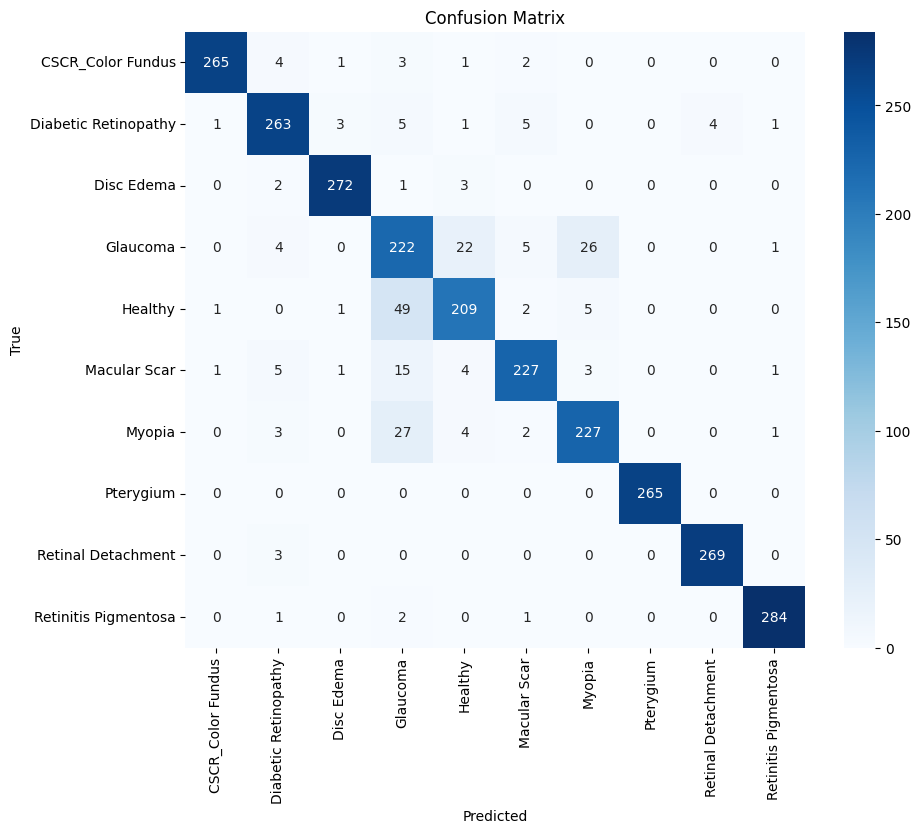

In [ ]:
import torch
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in val_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())


cm = confusion_matrix(all_labels, all_preds)
report = classification_report(all_labels, all_preds, digits=4)

print("Classification Report:\n")
print(report)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

In [ ]:
class_mapping = train_loader.dataset.dataset.class_to_idx
print(class_mapping)

{'CSCR_Color Fundus': 0, 'Diabetic Retinopathy': 1, 'Disc Edema': 2, 'Glaucoma': 3, 'Healthy': 4, 'Macular Scar': 5, 'Myopia': 6, 'Pterygium': 7, 'Retinal Detachment': 8, 'Retinitis Pigmentosa': 9}
